In [2]:
print("Pairs trading project started")

Pairs trading project started


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


# Statistical Arbitrage Using Cointegrated Pairs

## Project idea

This project tests a simple pairs trading strategy using Coca-Cola (KO) and PepsiCo (PEP).

The idea is that if two related stocks move together historically, temporary divergence between them may create a trading opportunity.

## Steps

1. Download stock price data
2. Plot KO and PEP prices
3. Estimate the relationship between the two stocks
4. Build the spread
5. Convert spread into z-score
6. Generate trading signals
7. Backtest the strategy
8. Evaluate performance

In [4]:
#!pip install yfinance

In [5]:
import yfinance as yf

In [6]:
tickers = ["KO", "PEP"]

data = yf.download(tickers, start="2020-01-01", end="2025-12-31")

data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                   High                    Low  \
Ticker             KO         PEP         KO         PEP         KO   
Date                                                                  
2020-01-02  45.141270  109.772446  45.502464  110.912026  44.952460   
2020-01-03  44.894985  109.618896  45.141258  110.556422  44.402447   
2020-01-06  44.878578  110.039154  45.075595  110.176562  44.755445   
2020-01-07  44.533802  108.309570  44.821116  109.974514  44.451713   
2020-01-08  44.615898  108.867249  44.853960  109.400677  44.451721   

Price                        Open                Volume           
Ticker             PEP         KO         PEP        KO      PEP  
Date                                                              
2020-01-02  109.222850  45.412165  110.621067  11867700  3784100  
2020-01-03  109.214786  44.591253  109.481501  11354500  4000100  
2020-01-06  109.271347  44.862163  109.352174  14698300  4085100  
2020-01-07  108.261079  44.697983  109.917933   9973900  5718100  
2020-01-08  108.358078  44.550228  108.673284  10676000  3681400

In [7]:
prices = data["Close"]

prices.head()

Ticker,KO,PEP
Date,,
2020-01-02,45.141270,109.772446
2020-01-03,44.894985,109.618896
2020-01-06,44.878578,110.039154
2020-01-07,44.533802,108.309570
2020-01-08,44.615898,108.867249


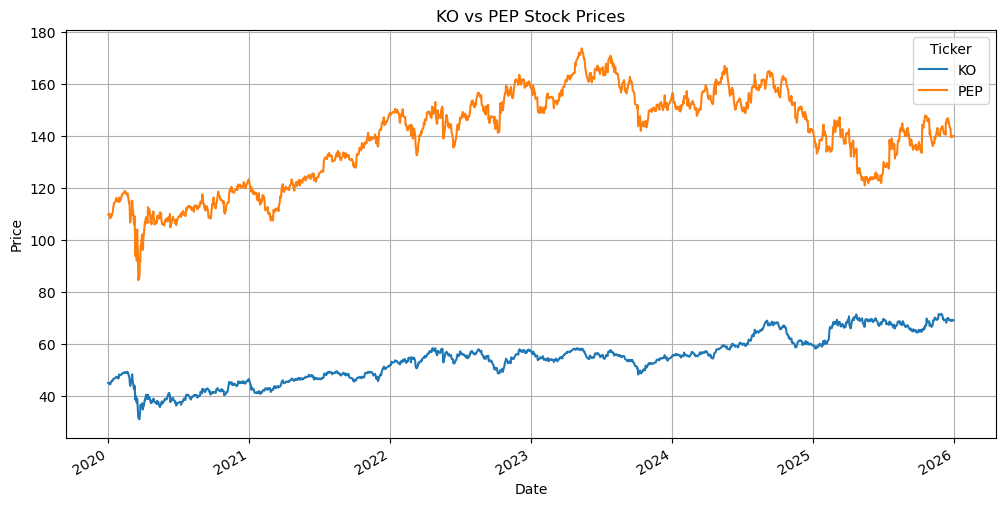

In [8]:
prices.plot(figsize=(12, 6))

plt.title("KO vs PEP Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

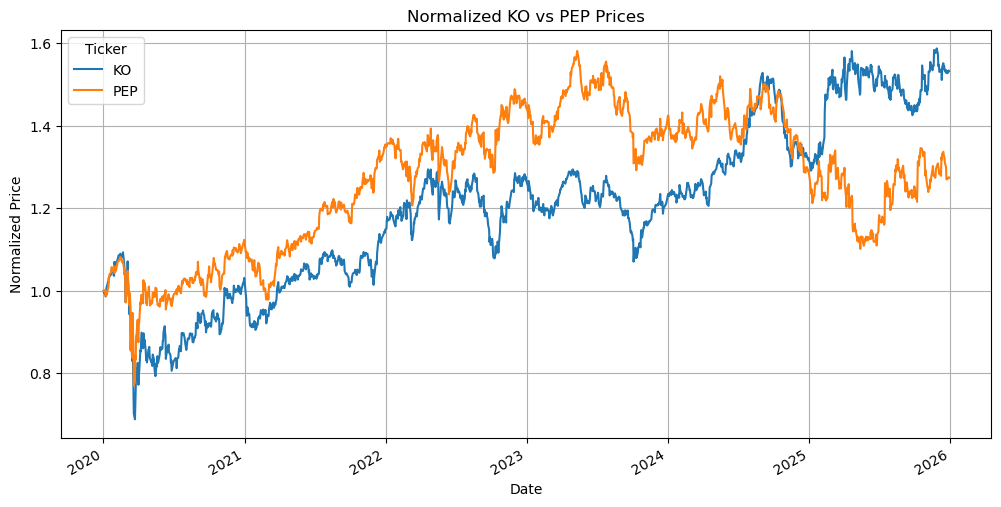

In [9]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))

plt.title("Normalized KO vs PEP Prices")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

In [10]:
import os
os.getcwd()

'/Users/didar/projects/pairs-trading-statistical-arbitrage'

Hedge Ratio (Beta): 0.3020


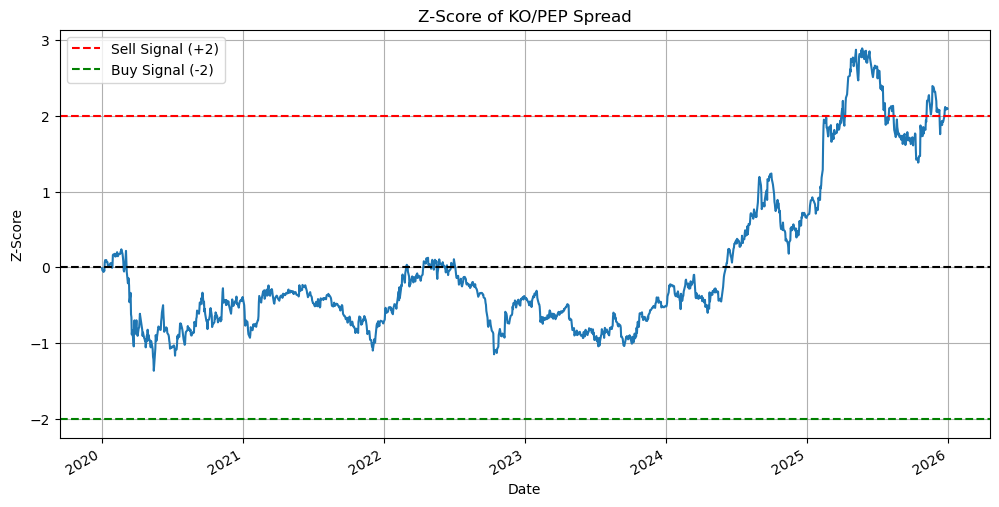

In [11]:
import statsmodels.api as sm

# 1. Считаем отношение цен (Hedge Ratio / Beta) через линейную регрессию OLS
X = sm.add_constant(prices['PEP']) 
model = sm.OLS(prices['KO'], X).fit()
beta = model.params['PEP']

print(f"Hedge Ratio (Beta): {beta:.4f}")

# 2. Строим Спред (Spread = KO - Beta * PEP)
spread = prices['KO'] - beta * prices['PEP']

# 3. Считаем Z-Score
mean = spread.mean()
std = spread.std()
z_score = (spread - mean) / std

# 4. Рисуем Z-score и торговые пороги (+2 и -2)
plt.figure(figsize=(12, 6))
z_score.plot()
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2.0, color='red', linestyle='--', label='Sell Signal (+2)')
plt.axhline(-2.0, color='green', linestyle='--', label='Buy Signal (-2)')
plt.title("Z-Score of KO/PEP Spread")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def backtest(prices, beta, threshold):
    df = pd.DataFrame(index=prices.index)
    df['KO'] = prices['KO']
    df['PEP'] = prices['PEP']
    df['Spread'] = spread
    df['Z_Score'] = z_score

    df['Positions_KO'] = np.where(df['Z_Score'] < -threshold, 1, np.where(df['Z_Score'] > threshold, -1, 0))
    df['Positions_PEP'] = -beta * df['Positions_KO']
    df['Positions_KO'] = df['Positions_KO'].shift(1)
    df['Positions_PEP'] = df['Positions_PEP'].shift(1)

    df['Returns_KO'] = df['KO'].pct_change()
    df['Returns_PEP'] = df['PEP'].pct_change()

    df['Strategy_Returns'] = (df['Positions_KO'] * df['Returns_KO']) + (df['Positions_PEP'] * df['Returns_PEP'])
    df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

    return df

In [13]:
df_conservative = backtest(prices, beta, threshold=2.0)
df_aggressive = backtest(prices, beta, threshold=1.0)

total_return_conservative = (df_conservative['Cumulative_Returns'].iloc[-1] - 1) * 100
total_return_aggressive = (df_aggressive['Cumulative_Returns'].iloc[-1] - 1) * 100

print(f"Conservative (Z=2.0) Return: {total_return_conservative:.2f}%")
print(f"Aggressive (Z=1.0) Return: {total_return_aggressive:.2f}%")

Conservative (Z=2.0) Return: 0.77%
Aggressive (Z=1.0) Return: 23.06%


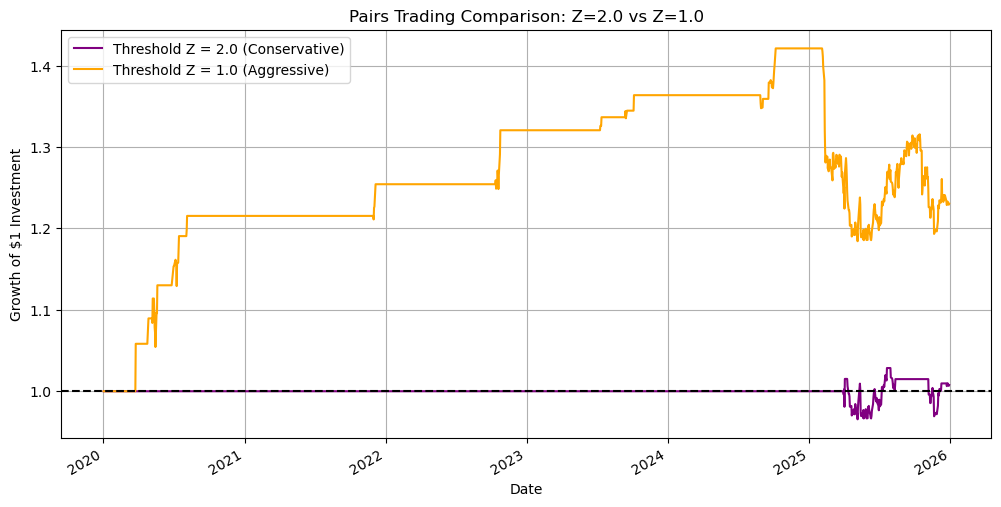

In [14]:
plt.figure(figsize=(12, 6))
df_conservative['Cumulative_Returns'].plot(label='Threshold Z = 2.0 (Conservative)', color='purple')
df_aggressive['Cumulative_Returns'].plot(label='Threshold Z = 1.0 (Aggressive)', color='orange')
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Pairs Trading Comparison: Z=2.0 vs Z=1.0")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
returns = df_aggressive['Strategy_Returns'].dropna()

sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)

cum_rets = df_aggressive['Cumulative_Returns']
peak = cum_rets.cummax()
drawdown = (cum_rets - peak) / peak
max_drawdown = drawdown.min() * 100

print(f"--- Strategy Performance Metrics (Z=1.0) ---")
print(f"Total Return: {total_return_aggressive:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

--- Strategy Performance Metrics (Z=1.0) ---
Total Return: 23.06%
Sharpe Ratio: 0.50
Max Drawdown: -16.67%


In [16]:
# 1. Разделение на Train (60%) и Test (40%)
train_size = int(len(prices) * 0.6)
train_df = prices.iloc[:train_size].copy()
test_df = prices.iloc[train_size:].copy()

# 2. Обучение OLS ТОЛЬКО на Train data
X_train = sm.add_constant(train_df['PEP'])
model_train = sm.OLS(train_df['KO'], X_train).fit()
beta_train = model_train.params['PEP']

# 3. Применение Beta к Test data (Out-of-Sample)
train_df['Spread'] = train_df['KO'] - beta_train * train_df['PEP']
test_df['Spread'] = test_df['KO'] - beta_train * test_df['PEP']
test_df['Mean'] = train_df['Spread'].mean()  # Среднее берем из TRAIN!
test_df['Std'] = train_df['Spread'].std()    # Std берем из TRAIN!
test_df['Z_Score'] = (test_df['Spread'] - test_df['Mean']) / test_df['Std']

# 4. Простой бэктест на Test data (Z = 1.0)
test_df['Position_KO'] = 0
test_df.loc[test_df['Z_Score'] > 1.0, 'Position_KO'] = -1
test_df.loc[test_df['Z_Score'] < -1.0, 'Position_KO'] = 1
test_df.loc[abs(test_df['Z_Score']) < 0.2, 'Position_KO'] = 0
test_df['Position_KO'] = test_df['Position_KO'].ffill().fillna(0)

test_df['KO_Returns'] = test_df['KO'].pct_change()
test_df['PEP_Returns'] = test_df['PEP'].pct_change()
test_df['Strategy_Returns'] = test_df['Position_KO'] * (test_df['KO_Returns'] - beta_train * test_df['PEP_Returns'])
test_df['OOS_Cumulative_Returns'] = (1 + test_df['Strategy_Returns']).cumprod()

print(f"Train Beta: {beta_train:.4f}")
print(f"Out-of-Sample Return: {(test_df['OOS_Cumulative_Returns'].iloc[-1] - 1) * 100:.2f}%")

Train Beta: 0.3022
Out-of-Sample Return: -27.82%


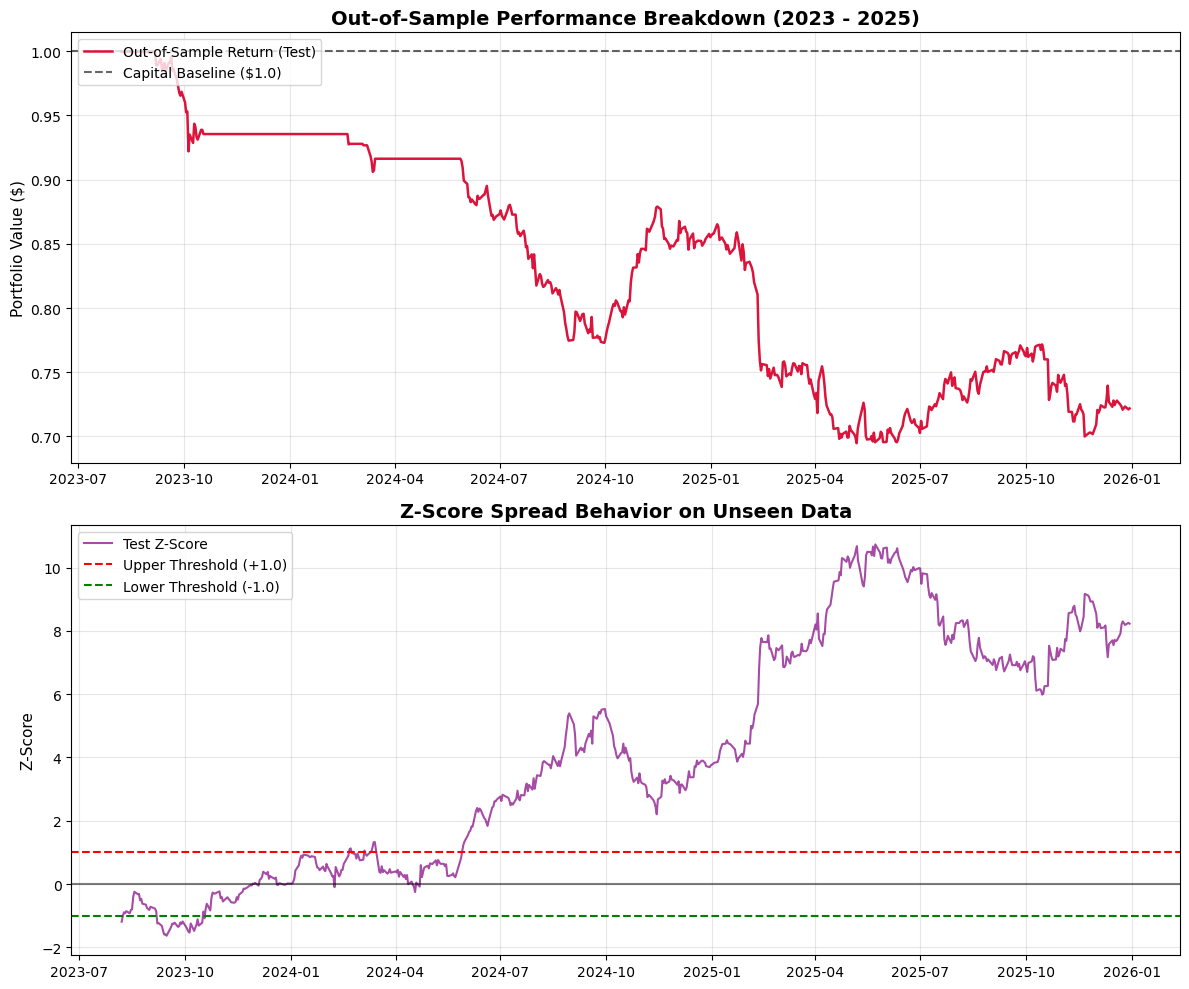

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# График 1: Out-of-Sample Накопленная Доходность (OOS Return)
axes[0].plot(test_df.index, test_df['OOS_Cumulative_Returns'], color='crimson', linewidth=1.8, label='Out-of-Sample Return (Test)')
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Capital Baseline ($1.0)')
axes[0].set_title('Out-of-Sample Performance Breakdown (2023 - 2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($)', fontsize=11)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# График 2: Z-Score спреда на Test периоде и линии входа
axes[1].plot(test_df.index, test_df['Z_Score'], color='purple', alpha=0.7, label='Test Z-Score')
axes[1].axhline(1.0, color='red', linestyle='--', label='Upper Threshold (+1.0)')
axes[1].axhline(-1.0, color='green', linestyle='--', label='Lower Threshold (-1.0)')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.5)
axes[1].set_title('Z-Score Spread Behavior on Unseen Data', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Z-Score', fontsize=11)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(train_df['KO'], train_df['PEP'])
print(f"Cointegration test p-value: {pvalue:.4f}")

Cointegration test p-value: 0.1345


In [19]:
mid = len(train_df) // 2
sub1 = train_df.iloc[:mid]
sub2 = train_df.iloc[mid:]

score1, p1, _ = coint(sub1['KO'], sub1['PEP'])
score2, p2, _ = coint(sub2['KO'], sub2['PEP'])
print(f"Sub-period 1 p-value: {p1:.4f}")
print(f"Sub-period 2 p-value: {p2:.4f}")

Sub-period 1 p-value: 0.2574
Sub-period 2 p-value: 0.3471


In [20]:
score_log, pvalue_log, _ = coint(np.log(train_df['KO']), np.log(train_df['PEP']))
print(f"Cointegration test (log prices) p-value: {pvalue_log:.4f}")

Cointegration test (log prices) p-value: 0.0588


In [21]:
data_old = yf.download(["KO", "PEP"], start="2015-01-01", end="2019-12-31")
prices_old = data_old["Close"]

score_old, pvalue_old, _ = coint(np.log(prices_old['KO']), np.log(prices_old['PEP']))
print(f"Cointegration test 2015-2019 (log prices) p-value: {pvalue_old:.4f}")

[*********************100%***********************]  2 of 2 completed

Cointegration test 2015-2019 (log prices) p-value: 0.1013


In [22]:
window_beta = 252
window_z = 60

log_KO = np.log(prices['KO'])
log_PEP = np.log(prices['PEP'])

rolling_beta = log_PEP.rolling(window_beta).cov(log_KO) / log_PEP.rolling(window_beta).var()

spread_rolling = log_KO - rolling_beta * log_PEP

z_rolling = (spread_rolling - spread_rolling.rolling(window_z).mean()) / spread_rolling.rolling(window_z).std()

Date
2020-12-30    1.206938
2020-12-31    1.208026
2021-01-04    1.209031
2021-01-05    1.208218
2021-01-06    1.208773
dtype: float64


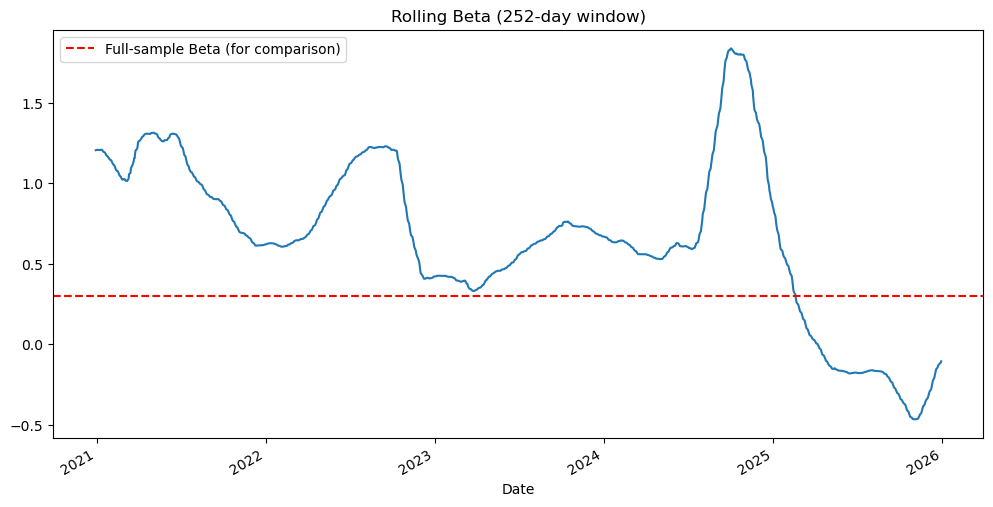

In [23]:
print(rolling_beta.dropna().head())
rolling_beta.plot(figsize=(12, 6), title="Rolling Beta (252-day window)")
plt.axhline(beta, color='red', linestyle='--', label='Full-sample Beta (for comparison)')
plt.legend()
plt.show()

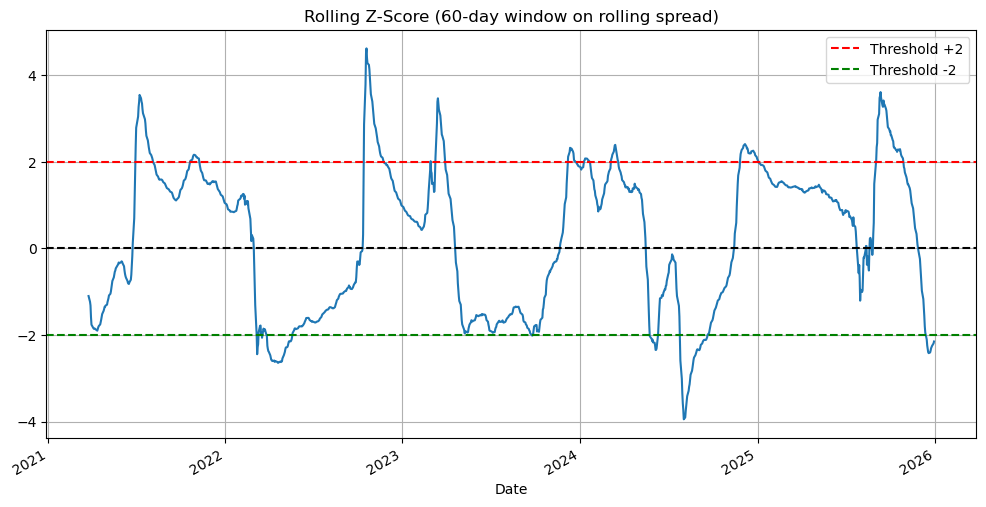

In [24]:
z_rolling.dropna().plot(figsize=(12, 6), title="Rolling Z-Score (60-day window on rolling spread)")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2.0, color='red', linestyle='--', label='Threshold +2')
plt.axhline(-2.0, color='green', linestyle='--', label='Threshold -2')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
def backtest_rolling(prices, rolling_beta, spread_rolling, z_rolling, threshold):
    df = pd.DataFrame(index=prices.index)
    df['KO'] = prices['KO']
    df['PEP'] = prices['PEP']
    df['Beta'] = rolling_beta
    df['Spread'] = spread_rolling
    df['Z_Score'] = z_rolling

    df['Positions_KO'] = np.where(df['Z_Score'] < -threshold, 1, np.where(df['Z_Score'] > threshold, -1, 0))
    df['Positions_PEP'] = -df['Beta'] * df['Positions_KO']

    df['Positions_KO'] = df['Positions_KO'].shift(1)
    df['Positions_PEP'] = df['Positions_PEP'].shift(1)

    df['Returns_KO'] = df['KO'].pct_change()
    df['Returns_PEP'] = df['PEP'].pct_change()

    df['Strategy_Returns'] = (df['Positions_KO'] * df['Returns_KO']) + (df['Positions_PEP'] * df['Returns_PEP'])
    df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

    return df.dropna(subset=['Z_Score'])

Rolling Beta/Z-Score Strategy Return: -1.35%


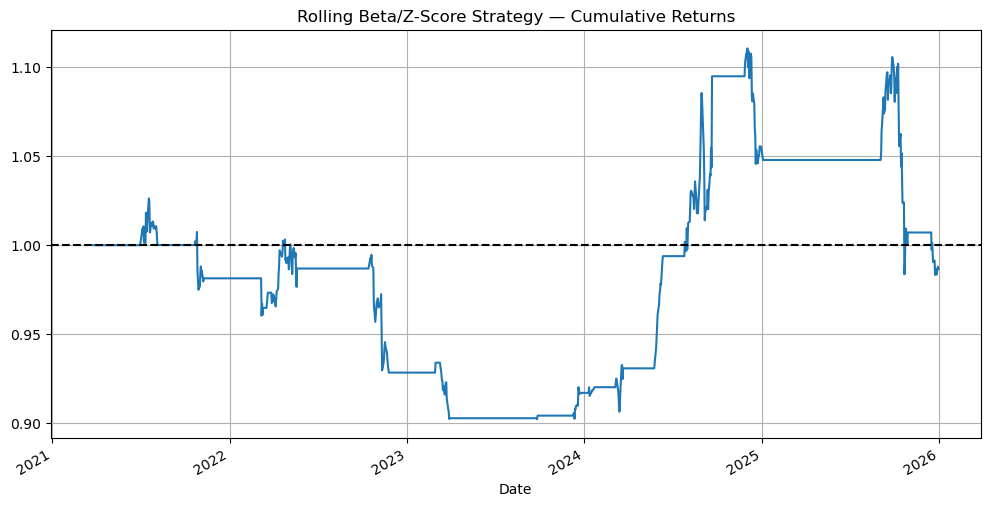

In [26]:
df_rolling = backtest_rolling(prices, rolling_beta, spread_rolling, z_rolling, threshold=2.0)

total_return_rolling = (df_rolling['Cumulative_Returns'].iloc[-1] - 1) * 100
print(f"Rolling Beta/Z-Score Strategy Return: {total_return_rolling:.2f}%")

df_rolling['Cumulative_Returns'].plot(figsize=(12,6), title="Rolling Beta/Z-Score Strategy — Cumulative Returns")
plt.axhline(1.0, color='black', linestyle='--')
plt.grid(True)
plt.show()

In [27]:
def apply_costs(df, cost_bps=5): #adding costs: 5 bps
    position_change = df['Positions_KO'].diff().abs() + df['Positions_PEP'].diff().abs()
    cost = position_change * (cost_bps / 10000)
    df['Strategy_Returns_net'] = df['Strategy_Returns'] - cost
    df['Cumulative_Returns_net'] = (1 + df['Strategy_Returns_net'].fillna(0)).cumprod()
    return df

Gross Return: -1.35%
Net Return (after 5bps costs): -4.24%


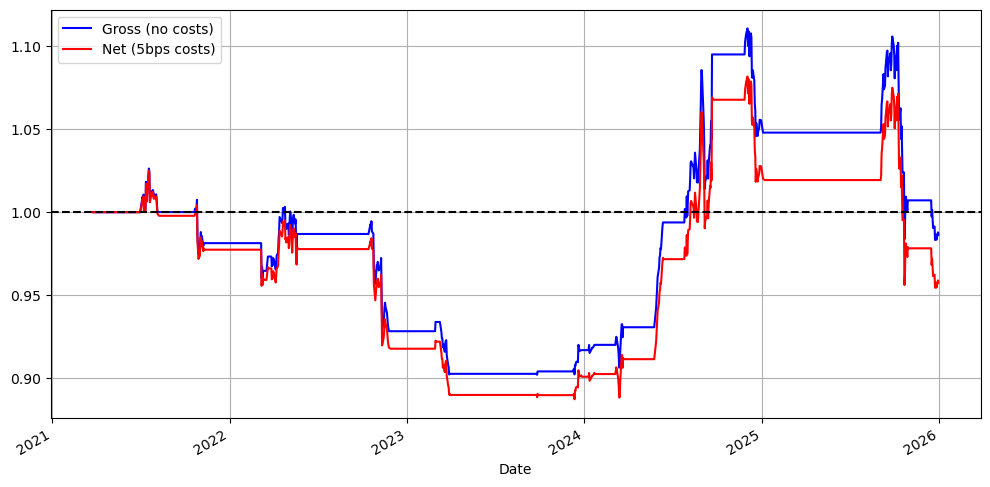

In [28]:
df_rolling = apply_costs(df_rolling, cost_bps=5)

print(f"Gross Return: {(df_rolling['Cumulative_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Net Return (after 5bps costs): {(df_rolling['Cumulative_Returns_net'].iloc[-1] - 1) * 100:.2f}%")

plt.figure(figsize=(12, 6))
df_rolling['Cumulative_Returns'].plot(label='Gross (no costs)', color='blue')
df_rolling['Cumulative_Returns_net'].plot(label='Net (5bps costs)', color='red')
plt.axhline(1.0, color='black', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
def calculate_weights(beta): #adjusting to dollar neutral weights
    weight_KO = 1 / (1 + abs(beta))
    weight_PEP = abs(beta) / (1 + abs(beta))
    return weight_KO, weight_PEP

In [30]:
def backtest_weighted(prices, rolling_beta, spread_rolling, z_rolling, threshold):
    df = pd.DataFrame(index=prices.index)
    df['KO'] = prices['KO']
    df['PEP'] = prices['PEP']
    df['Beta'] = rolling_beta
    df['Spread'] = spread_rolling
    df['Z_Score'] = z_rolling

    df['Signal'] = np.where(df['Z_Score'] < -threshold, 1, np.where(df['Z_Score'] > threshold, -1, 0))
    df['Signal'] = df['Signal'].shift(1)

    weight_KO, weight_PEP = calculate_weights(df['Beta'])
    df['Weight_KO'] = weight_KO
    df['Weight_PEP'] = weight_PEP

    df['Returns_KO'] = df['KO'].pct_change()
    df['Returns_PEP'] = df['PEP'].pct_change()

    df['Strategy_Returns'] = df['Signal'] * (df['Weight_KO'] * df['Returns_KO'] - df['Weight_PEP'] * df['Returns_PEP'])
    df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

    df['Positions_KO'] = df['Signal']
    df['Positions_PEP'] = -df['Signal']
    
    return df.dropna(subset=['Z_Score'])

Gross Return: 0.58%
Net Return (after 5bps costs): -2.69%


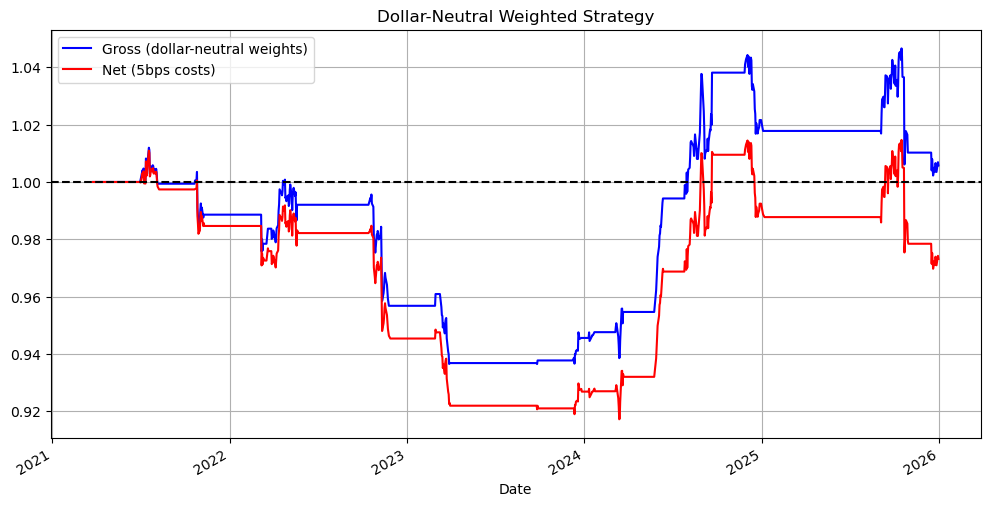

In [31]:
df_weighted = backtest_weighted(prices, rolling_beta, spread_rolling, z_rolling, threshold=2.0)
df_weighted = apply_costs(df_weighted, cost_bps=5)

print(f"Gross Return: {(df_weighted['Cumulative_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Net Return (after 5bps costs): {(df_weighted['Cumulative_Returns_net'].iloc[-1] - 1) * 100:.2f}%")

plt.figure(figsize=(12, 6))
df_weighted['Cumulative_Returns'].plot(label='Gross (dollar-neutral weights)', color='blue')
df_weighted['Cumulative_Returns_net'].plot(label='Net (5bps costs)', color='red')
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Dollar-Neutral Weighted Strategy")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
def backtest_state_machine(prices, rolling_beta, z_rolling, threshold=2.0, stop_threshold=4, max_days=60):
    df = pd.DataFrame(index=prices.index)
    df['KO'] = prices['KO']
    df['PEP'] = prices['PEP']
    df['Beta'] = rolling_beta
    df['Z_Score'] = z_rolling
    df = df.dropna(subset=['Z_Score']).copy()

    position = 0        # 0 = out of position, 1 = long spread, -1 = short spread
    entry_day = None
    signals = []

    z_values = df['Z_Score'].values

    for i in range(len(df)):
        z = z_values[i]

        if position == 0:
            # вход: только если сейчас плоско (нет открытой позиции)
            if z < -threshold:
                position = 1
                entry_day = i
            elif z > threshold:
                position = -1
                entry_day = i
        else:
            days_in_trade = i - entry_day
            exit_trade = False

            # 1. Return-to-mean: спред дошёл обратно до нуля
            if position == 1 and z >= -0.5:
                exit_trade = True
            elif position == -1 and z <= 0.5:
                exit_trade = True
            # 2. Stop-loss: отклонение стало ещё сильнее, чем было при входе
            elif abs(z) > stop_threshold:
                exit_trade = True
            # 3. Time-stop: позиция держится слишком долго без результата
            elif days_in_trade >= max_days:
                exit_trade = True

            if exit_trade:
                position = 0
                entry_day = None

        signals.append(position)

    df['Signal'] = signals
    df['Signal'] = df['Signal'].shift(1)  # торгуем на следующий день после сигнала

    weight_KO, weight_PEP = calculate_weights(df['Beta'])
    df['Weight_KO'] = weight_KO
    df['Weight_PEP'] = weight_PEP

    df['Returns_KO'] = df['KO'].pct_change()
    df['Returns_PEP'] = df['PEP'].pct_change()

    df['Strategy_Returns'] = df['Signal'] * (df['Weight_KO'] * df['Returns_KO'] - df['Weight_PEP'] * df['Returns_PEP'])
    df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

    df['Positions_KO'] = df['Signal']
    df['Positions_PEP'] = -df['Signal']

    return df

Gross Return: -14.32%
Net Return (after 5bps costs): -16.94%


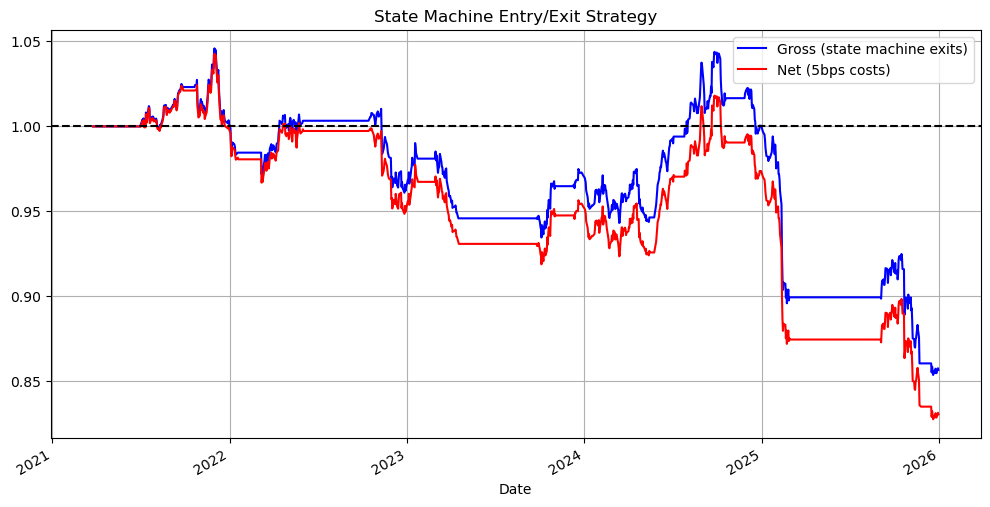

In [33]:
df_sm = backtest_state_machine(prices, rolling_beta, z_rolling, threshold=2.0, stop_threshold=4, max_days=60)
df_sm = apply_costs(df_sm, cost_bps=5)

print(f"Gross Return: {(df_sm['Cumulative_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Net Return (after 5bps costs): {(df_sm['Cumulative_Returns_net'].iloc[-1] - 1) * 100:.2f}%")

plt.figure(figsize=(12, 6))
df_sm['Cumulative_Returns'].plot(label='Gross (state machine exits)', color='blue')
df_sm['Cumulative_Returns_net'].plot(label='Net (5bps costs)', color='red')
plt.axhline(1.0, color='black', linestyle='--')
plt.title("State Machine Entry/Exit Strategy")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
for bps in [0, 5, 10, 20]: #checking the effect of different bps
    df_temp = backtest_state_machine(prices, rolling_beta, z_rolling, threshold=2.0, stop_threshold=4.0, max_days=60)
    df_temp = apply_costs(df_temp, cost_bps=bps)
    net_return = (df_temp['Cumulative_Returns_net'].iloc[-1] - 1) * 100
    print(f"Costs = {bps} bps: Net Return = {net_return:.2f}%")

Costs = 0 bps: Net Return = -14.32%
Costs = 5 bps: Net Return = -16.94%
Costs = 10 bps: Net Return = -19.48%
Costs = 20 bps: Net Return = -24.33%


##### At this point my additional exit conditions significantly worsen the model from the almost zero return to -14% and worse. Let's investigate..

In [35]:
n_trades_sm = (df_sm['Signal'].diff().abs() > 0).sum()
n_trades_weighted = (df_weighted['Positions_KO'].diff().abs() > 0).sum()

print(f"State machine: {n_trades_sm} position changes")
print(f"Simple weighted: {n_trades_weighted} position changes")

State machine: 31 position changes
Simple weighted: 33 position changes


In [36]:
avg_return_per_trade_sm = df_sm.loc[df_sm['Signal'] != 0, 'Strategy_Returns'].mean()
avg_return_per_trade_weighted = df_weighted.loc[df_weighted['Positions_KO'] != 0, 'Strategy_Returns'].mean()

print(f"State machine avg daily return while in position: {avg_return_per_trade_sm:.5f}")
print(f"Simple weighted avg daily return while in position: {avg_return_per_trade_weighted:.5f}")

State machine avg daily return while in position: -0.00024
Simple weighted avg daily return while in position: 0.00003


### Summary of worse returns after introducing exit conditionals
##### Trade counts are nearly identical(33 vs 31) given such a different returns. Diagnosis: while in a position, state-machine ignores new signals until one of its 3 exit conditions occurs, causing longer holds through unfavorable periods.
##### Compared to the simple version's daily signal re-evaluation. Not a bug but a real trade-off between reactive vs formal exit logic, worse here due to unstable rolling beta.

## Screening of cointegrated tickers
Since PEP and KO aren't proven to be cointegrated, next step is going to be a screening of cointegrated pairs of tickers. Chosen sectors are Consumer Staples, Banks, Tech Hardware.

In [37]:
sectors = {
    'Consumer_Staples': ['KO', 'PEP', 'MDLZ', 'GIS', 'KHC', 'HSY', 'STZ', 'KDP'],
    'Banks': ['JPM', 'BAC', 'WFC', 'C', 'USB', 'PNC', 'TFC', 'COF'],
    'Tech_Hardware': ['AAPL', 'MSFT', 'CSCO', 'HPQ', 'IBM', 'ORCL', 'INTC', 'TXN']
}

all_tickers = [t for tickers in sectors.values() for t in tickers]

data_formation = yf.download(all_tickers, start="2015-01-01", end="2019-12-31")
prices_formation = data_formation["Close"]

prices_formation.head()

[*********************100%***********************]  24 of 24 completed


Ticker,AAPL,BAC,C,COF,CSCO,GIS,HPQ,HSY,IBM,INTC,...,MDLZ,MSFT,ORCL,PEP,PNC,STZ,TFC,TXN,USB,WFC
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.171755,13.979475,39.811577,66.788383,19.530848,34.529427,12.426950,78.041023,96.164093,27.896450,...,28.337927,39.607193,37.224056,65.879150,62.852100,81.734177,24.434629,38.903561,29.921509,39.509289
2015-01-05,23.490805,13.573361,38.556923,65.250061,19.141785,33.905270,12.220038,77.491699,94.650948,27.581892,...,27.914291,39.242966,36.702019,65.383873,60.928188,83.679031,23.663342,38.299778,29.200672,38.425846
2015-01-06,23.493010,13.167258,37.199543,64.035591,19.134722,33.820766,12.127390,77.747536,92.609688,27.067848,...,27.721724,38.666977,36.323128,64.888580,59.350323,84.215530,23.201834,37.666912,28.813541,37.624115
2015-01-07,23.822437,13.229734,37.544380,64.764252,19.311562,34.535923,12.269448,79.117081,92.004471,27.635605,...,28.592115,39.158257,36.331558,66.786003,60.035458,86.386719,23.511616,38.343437,29.067175,37.848026
2015-01-08,24.737740,13.503076,38.109360,65.395790,19.460108,35.099415,12.562826,80.644661,94.004173,28.149647,...,28.954142,40.310200,36.550461,67.999794,61.191143,90.234535,23.903576,38.969028,29.280752,38.685890


In [38]:
from itertools import combinations

results = []

for sector, tickers in sectors.items():
    pairs = list(combinations(tickers, 2))
    for t1, t2 in pairs:
        try:
            log_p1 = np.log(prices_formation[t1].dropna())
            log_p2 = np.log(prices_formation[t2].dropna())
            common_idx = log_p1.index.intersection(log_p2.index)
            score, pvalue, _ = coint(log_p1.loc[common_idx], log_p2.loc[common_idx])
            results.append({'sector': sector, 'pair': f"{t1}-{t2}", 'pvalue': pvalue})
        except Exception as e:
            print(f"Failed on {t1}-{t2}: {e}")

results_df = pd.DataFrame(results)
results_df.sort_values('pvalue').head(10)

,sector,pair,pvalue
39,Banks,BAC-TFC,0.006412
38,Banks,BAC-PNC,0.011253
54,Banks,PNC-COF,0.018177
49,Banks,C-COF,0.019007
14,Consumer_Staples,MDLZ-KHC,0.019335
55,Banks,TFC-COF,0.026207
33,Banks,JPM-TFC,0.028566
45,Banks,WFC-COF,0.032007
10,Consumer_Staples,PEP-HSY,0.034014
82,Tech_Hardware,ORCL-TXN,0.034816


In [39]:
n_total = len(results_df)
n_passed = (results_df['pvalue'] < 0.05).sum()
expected_by_chance = n_total * 0.05
print(f"Total pairs tested: {n_total}")
print(f"Passed p<0.05: {n_passed}")
print(f"Expected by chance alone: {expected_by_chance:.1f}")

Total pairs tested: 84
Passed p<0.05: 12
Expected by chance alone: 4.2


#### Screening result: 
##### 12 of 84 intra-sector pairs passed p<0.05, vs 4.2 expected by chance alone, which is more than expected, but not by a wide margin. Under a stricter Bonferroni-corrected threshold (0.0006 for 84 tests), none of the 12 would survive. Treating the ranking as a shortlist rather than proof, taking the top 3 (all banks: BAC-TFC, BAC-PNC, PNC-COF) forward to out-of-sample testing on 2020-2026.

In [40]:
oos_tickers = ["BAC", "TFC", "PNC", "COF"]
data_oos = yf.download(oos_tickers, start="2020-01-01", end="2026-01-01")
prices_oos = data_oos["Close"]

[*********************100%***********************]  4 of 4 completed


In [41]:
def compute_rolling_signals(price1, price2, window_beta=252, window_z=60): #general function
    log_p1 = np.log(price1)
    log_p2 = np.log(price2)
    r_beta = log_p2.rolling(window_beta).cov(log_p1) / log_p2.rolling(window_beta).var()
    spread = log_p1 - r_beta * log_p2
    z = (spread - spread.rolling(window_z).mean()) / spread.rolling(window_z).std()
    return r_beta, spread, z

In [42]:
def backtest_generic(price1, price2, r_beta, z, threshold=2.0):
    df = pd.DataFrame(index=price1.index)
    df['P1'] = price1
    df['P2'] = price2
    df['Beta'] = r_beta
    df['Z_Score'] = z
    df = df.dropna(subset=['Z_Score']).copy()

    df['Signal'] = np.where(df['Z_Score'] < -threshold, 1, np.where(df['Z_Score'] > threshold, -1, 0))
    df['Signal'] = df['Signal'].shift(1)

    w1, w2 = calculate_weights(df['Beta'])
    df['Returns_P1'] = df['P1'].pct_change()
    df['Returns_P2'] = df['P2'].pct_change()

    df['Strategy_Returns'] = df['Signal'] * (w1 * df['Returns_P1'] - w2 * df['Returns_P2'])
    df['Cumulative_Returns'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()

    df['Positions_KO'] = df['Signal']
    df['Positions_PEP'] = -df['Signal']
    return df

In [43]:
candidates = [("BAC", "TFC"), ("BAC", "PNC"), ("PNC", "COF")]

for t1, t2 in candidates:
    r_beta, spread, z = compute_rolling_signals(prices_oos[t1], prices_oos[t2])
    df_pair = backtest_generic(prices_oos[t1], prices_oos[t2], r_beta, z, threshold=2.0)
    df_pair = apply_costs(df_pair, cost_bps=5)
    net_return = (df_pair['Cumulative_Returns_net'].iloc[-1] - 1) * 100
    print(f"{t1}-{t2}: Net Return (5bps) = {net_return:.2f}%")

BAC-TFC: Net Return (5bps) = -3.84%
BAC-PNC: Net Return (5bps) = -9.11%
PNC-COF: Net Return (5bps) = 0.64%


In [44]:
def compute_metrics(df, label):
    returns = df['Strategy_Returns_net'].dropna()
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    
    cum = df['Cumulative_Returns_net']
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min() * 100
    
    total_return = (cum.iloc[-1] - 1) * 100
    n_years = len(df) / 252
    cagr = ((cum.iloc[-1]) ** (1 / n_years) - 1) * 100
    
    pct_in_market = (df['Signal'] != 0).mean() * 100
    
    print(f"{label}:")
    print(f"  Total Return: {total_return:.2f}%")
    print(f"  CAGR: {cagr:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.2f}")
    print(f"  Max Drawdown: {max_dd:.2f}%")
    print(f"  Time in Market: {pct_in_market:.1f}%")

compute_metrics(df_sm, "KO-PEP (state machine)")

KO-PEP (state machine):
  Total Return: -16.94%
  CAGR: -3.83%
  Sharpe Ratio: -0.71
  Max Drawdown: -20.63%
  Time in Market: 52.3%


In [45]:
oos_results = {}

for t1, t2 in candidates:
    r_beta, spread, z = compute_rolling_signals(prices_oos[t1], prices_oos[t2])
    df_pair = backtest_generic(prices_oos[t1], prices_oos[t2], r_beta, z, threshold=2.0)
    df_pair = apply_costs(df_pair, cost_bps=5)
    oos_results[f"{t1}-{t2}"] = df_pair
    compute_metrics(df_pair, f"{t1}-{t2}")

BAC-TFC:
  Total Return: -3.84%
  CAGR: -0.82%
  Sharpe Ratio: -0.14
  Max Drawdown: -7.58%
  Time in Market: 22.4%
BAC-PNC:
  Total Return: -9.11%
  CAGR: -1.99%
  Sharpe Ratio: -0.43
  Max Drawdown: -10.81%
  Time in Market: 21.3%
PNC-COF:
  Total Return: 0.64%
  CAGR: 0.13%
  Sharpe Ratio: 0.05
  Max Drawdown: -11.13%
  Time in Market: 24.2%


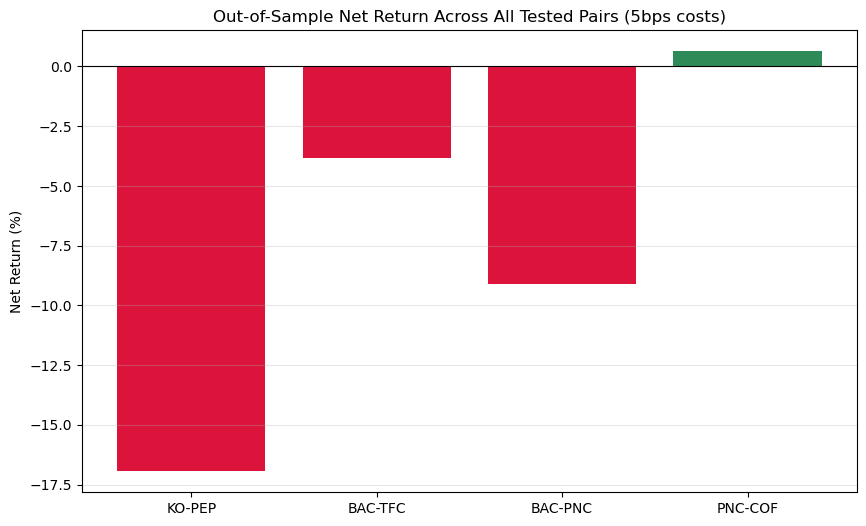

In [46]:
summary = {
    'KO-PEP': (df_sm['Cumulative_Returns_net'].iloc[-1] - 1) * 100,
}
for name, df in oos_results.items():
    summary[name] = (df['Cumulative_Returns_net'].iloc[-1] - 1) * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(summary.keys(), summary.values(), color=['crimson' if v < 0 else 'seagreen' for v in summary.values()])
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.title("Out-of-Sample Net Return Across All Tested Pairs (5bps costs)")
plt.ylabel("Net Return (%)")
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### Summary: Metrics Across All Tested Pairs

| Pair | Return | CAGR | Sharpe | Max DD | Time in Market |
|---|---|---|---|---|---|
| KO-PEP | -16.94% | -3.83% | -0.71 | -20.63% | 52.3% |
| BAC-TFC | -3.84% | -0.82% | -0.14 | -7.58% | 22.4% |
| BAC-PNC | -9.11% | -1.99% | -0.43 | -10.81% | 21.3% |
| PNC-COF | +0.64% | +0.13% | 0.05 | -11.13% | 24.2% |

None show a Sharpe above 0.1. KO-PEP trades most often and carries by far the largest drawdown; the three screened banking pairs trade less and stay in smaller drawdowns, but PNC-COF's marginal +0.64% (Sharpe 0.05) is statistical noise, not signal. The pattern holds across a pair chosen arbitrarily (KO-PEP) and pairs chosen through formal screening (BAC-TFC, BAC-PNC, PNC-COF) — no combination produces a Sharpe suggesting a tradeable edge.

##### This finding is consistent with published research: Do & Faff (2010, 2012) document that daily-frequency pairs trading profitability in US equities largely disappeared after the early 2000s, with what edge remains concentrated in intraday data and larger, factor-neutral universes (Avellaneda & Lee, 2010). My project reproduces this decline after fixing the biases in my first version, which originally showed an unexplained +23% that didn't survive scrutiny.